# Phase 1

In [23]:
import os
import pandas as pd
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

In [24]:
# Change this path to your dataset file
LOG_FILE = 'data/HDFS.log'
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
# 1. Load log file, count total lines
total_lines = sum(1 for _ in open(LOG_FILE, 'r', encoding='utf8', errors='ignore'))
print(f"Total lines in log file: {total_lines}")

Total lines in log file: 11175629


In [25]:
def parse_logs_with_drain(sim_th):
    config = TemplateMinerConfig()
    config.profiling_enabled = False  # Disable profiling for faster parsing
    config.drain_sim_th = sim_th
    miner = TemplateMiner(config=config)
    
    with open(LOG_FILE, 'r', encoding='utf8', errors='ignore') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if line:
                miner.add_log_message(line)
    
    templates = []
    for cluster in miner.drain.clusters:
        templates.append({
            'template_id': cluster.cluster_id,
            'template': cluster.get_template(),
            'count': cluster.size
        })
        
    df = pd.DataFrame(templates).sort_values('count', ascending=False)
    return df, miner
# 2. Tune drain_sim_th
print("Tuning drain_sim_th...")
for th in [0.3, 0.5, 0.7]:
    df_temp, _ = parse_logs_with_drain(th)
    print(f"Sim_th = {th} -> Number of templates generated: {len(df_temp)}")

Tuning drain_sim_th...
Sim_th = 0.3 -> Number of templates generated: 63
Sim_th = 0.5 -> Number of templates generated: 55


KeyboardInterrupt: 

In [26]:
# 3. Parse again with the best sim_th value (e.g., choose 0.5)
print("\nParsing all logs with sim_th = 0.5...")
df_templates, miner = parse_logs_with_drain(0.5)
# Export top-10 templates
top_10 = df_templates.head(10)
top_10.to_csv(os.path.join(RESULTS_DIR, 'top_templates.csv'), index=False)
print("Top 10 Templates have been saved to results/top_templates.csv:")
display(top_10)


Parsing all logs with sim_th = 0.5...
Top 10 Templates have been saved to results/top_templates.csv:


,template_id,template,count
0,1,<*> <*> <*> INFO dfs.DataNode$DataXceiver: Rec...,1723232
4,5,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...,1719741
3,4,<*> <*> <*> INFO dfs.DataNode$PacketResponder:...,1706514
16,17,<*> <*> <*> INFO dfs.FSDataset: Deleting block...,1402047
30,31,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...,1396174
48,49,081111 <*> <*> INFO dfs.DataNode$PacketRespond...,859939
35,36,081110 <*> <*> INFO dfs.DataNode$PacketRespond...,680085
33,34,<*> <*> <*> WARN dfs.DataNode$DataXceiver: <*>...,356207
37,38,081110 <*> <*> INFO dfs.DataNode$DataXceiver: ...,351415
47,48,081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...,288998


# Phase 2

In [27]:
import re
import os
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [33]:
def parse_time(line):
    # Optimized timestamp parsing for HDFS (e.g., 081109 203518)
    if len(line) >= 13 and line[6] == ' ' and line[:6].isdigit():
        try:
            return datetime(
                year=2000 + int(line[0:2]),
                month=int(line[2:4]),
                day=int(line[4:6]),
                hour=int(line[7:9]),
                minute=int(line[9:11]),
                second=int(line[11:13])
            )
        except ValueError:
            pass
    return None

def parse_block_id(line):
    # Extract blk_id for HDFS precision/recall
    match = re.search(r'(blk_[-]?\d+)', line)
    return match.group(1) if match else None

print("Creating records for Time Series...")
records = []
# You can uncomment the break condition below to test with a smaller subset first
with open(LOG_FILE, 'r', encoding='utf8', errors='ignore') as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line: continue
        
        dt = parse_time(line)
        blk = parse_block_id(line)
        
        if dt:
            cluster = miner.match(line) 
            if cluster:
                # Handle both dict and object depending on Drain3 version
                t_id = cluster['cluster_id'] if isinstance(cluster, dict) else cluster.cluster_id
                records.append({'time': dt, 'template_id': t_id, 'block_id': blk})
                
        # if i > 1000000: break # Uncomment this line if it takes too long to run

df_log = pd.DataFrame(records)
df_log.set_index('time', inplace=True)

# 1. Create template count time series (5-minute window)
df_ts = df_log.groupby([pd.Grouper(freq='5Min'), 'template_id']).size().unstack(fill_value=0)
# 2a. Total count per window (what the plot shows)
df_ts_total = df_ts.sum(axis=1)
# 2b. Approach A — 3σ (simple, interpretable)
mean, std = df_ts_total.mean(), df_ts_total.std()
df_ts['anomaly_3sigma'] = (df_ts_total > mean + 3 * std).map({True: -1, False: 1})
# 2c. Approach B — Isolation Forest on TOTAL count (1D), NOT all 55 columns
iso = IsolationForest(contamination=0.05, random_state=42)
df_ts['anomaly'] = iso.fit_predict(df_ts_total.values.reshape(-1, 1))
anomalies = df_ts[df_ts['anomaly'] == -1]
print(f"Detected {len(anomalies)} anomalous timeframes")




Creating records for Time Series...
Detected 24 anomalous timeframes


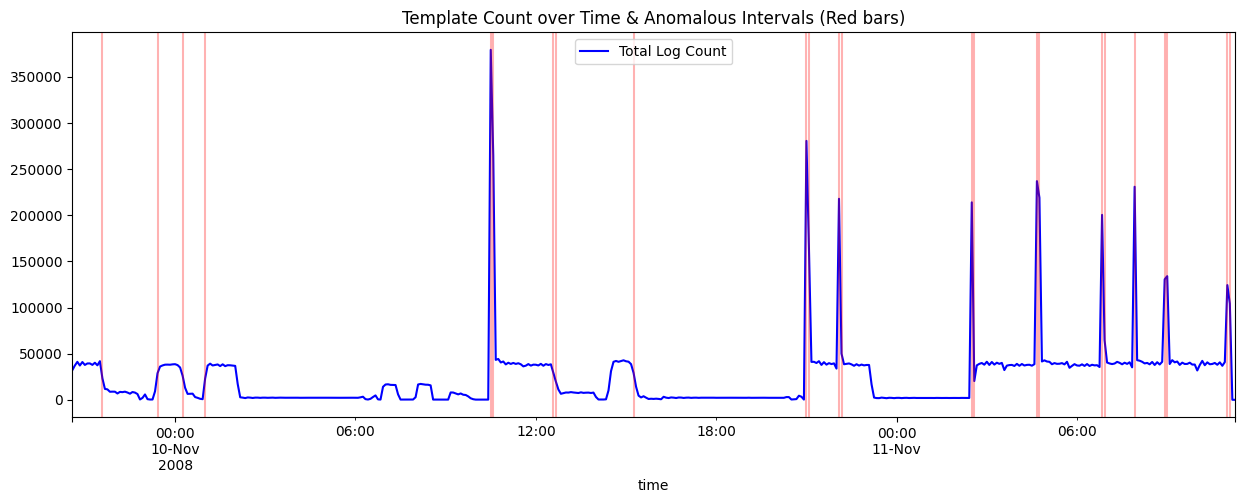


--- Spiking Templates in Anomalous Windows ---
Template ID 31 spiked 894.1x compared to normal!
Template ID 17 spiked 427.8x compared to normal!
Template ID 32 spiked 138.6x compared to normal!
Template ID 8 spiked 8.2x compared to normal!
Template ID 9 spiked 8.2x compared to normal!

--- First Appearance of Templates ---
Top 5 earliest templates:
template_id
1   2008-11-09 20:35:18
2   2008-11-09 20:35:18
3   2008-11-09 20:35:19
4   2008-11-09 20:35:19
5   2008-11-09 20:35:19
Name: time, dtype: datetime64[us]

Top 5 newest templates (first appeared last):
template_id
51   2008-11-11 03:32:55
52   2008-11-11 03:33:42
53   2008-11-11 04:39:36
54   2008-11-11 07:06:40
55   2008-11-11 07:10:32
Name: time, dtype: datetime64[us]

--- Precision / Recall (HDFS) ---
Evaluation on BlockId (Derived from Time-Series Anomaly Detection):
              precision    recall  f1-score   support

     Anomaly       0.02      0.62      0.04     16838
      Normal       0.94      0.19      0.32    55822

In [34]:
# Visualization
plt.figure(figsize=(15, 5))
df_ts.drop(columns=['anomaly']).sum(axis=1).plot(label='Total Log Count', color='blue')
for idx in anomalies.index:
    plt.axvline(x=idx, color='red', alpha=0.3)
plt.title("Template Count over Time & Anomalous Intervals (Red bars)")
plt.legend()
plt.show()

# --- Detect Spike Templates ---
print("\n--- Spiking Templates in Anomalous Windows ---")
normal_avg = df_ts[df_ts['anomaly'] == 1].drop(columns=['anomaly']).mean()
anomaly_avg = df_ts[df_ts['anomaly'] == -1].drop(columns=['anomaly']).mean()

# Templates with average count in anomaly windows significantly higher than normal (e.g. 3x)
diff = anomaly_avg / (normal_avg + 1e-5) 
spike_templates = diff[diff > 3].sort_values(ascending=False).head(5)
for t_id, ratio in spike_templates.items():
    print(f"Template ID {t_id} spiked {ratio:.1f}x compared to normal!")

# --- Detect first appearance of new templates ---
print("\n--- First Appearance of Templates ---")
df_first = df_log.reset_index().groupby('template_id')['time'].min().sort_values()
print("Top 5 earliest templates:")
print(df_first.head(5))
print("\nTop 5 newest templates (first appeared last):")
print(df_first.tail(5))

# --- Precision / Recall (HDFS) ---
print("\n--- Precision / Recall (HDFS) ---")
# HDFS evaluates anomalies by BlockId. We map our window-based anomalies to BlockIds.
# If a BlockId appears in ANY anomalous 5-minute window, it's flagged as an anomaly.
label_file = 'data/preprocessed/anomaly_label.csv' 
if os.path.exists(label_file):
    df_labels = pd.read_csv(label_file)
    
    # Associate predictions with original logs
    df_log_reset = df_log.reset_index()
    df_log_reset['time_window'] = df_log_reset['time'].dt.floor('5Min')
    
    pred_dict = df_ts['anomaly'].to_dict()
    df_log_reset['pred'] = df_log_reset['time_window'].map(pred_dict)
    
    # Predict a BlockId as anomaly (-1) if any of its logs fall in an anomalous window
    block_preds = df_log_reset.groupby('block_id')['pred'].min().reset_index()
    block_preds.columns = ['BlockId', 'Pred']
    
    # Map predictions to string labels to match ground truth format (Anomaly/Normal)
    block_preds['Pred_Label'] = block_preds['Pred'].map({-1: 'Anomaly', 1: 'Normal'})
    
    eval_df = pd.merge(df_labels, block_preds, on='BlockId', how='inner')
    
    if len(eval_df) > 0:
        from sklearn.metrics import classification_report
        print("Evaluation on BlockId (Derived from Time-Series Anomaly Detection):")
        print(classification_report(eval_df['Label'], eval_df['Pred_Label']))
    else:
        print("No matching BlockIds found between logs and labels.")
else:
    print(f"Label file not found: {label_file}")

# Phase 3

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans


In [31]:
# 1. TF-IDF on templates list
templates_list = df_templates['template'].tolist()
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(templates_list)
# 2. Calculate Similarity Matrix
sim_matrix = cosine_similarity(X)
print(f"Similarity Matrix Shape: {sim_matrix.shape}")
# 3. Find template clusters (Example: split into 5 clusters)
kmeans = KMeans(n_clusters=5, random_state=42)
df_templates['cluster'] = kmeans.fit_predict(X)
print("\nTemplate Clustering with K-Means:")
display(df_templates[['template_id', 'cluster', 'template']].head(10))
# 4. Inject 1 "strange" log (self-written)
strange_log = "081109 204000 999 FATAL SYSTEM_CORE: Core meltdown detected in reactor 4! Temperature > 9000C"
print(f"\nInjecting strange log: '{strange_log}'")
# Process with Drain3
new_cluster = miner.add_log_message(strange_log)
# FIX: access dictionary attributes using brackets
print(f"Drain3 classified into Template ID: {new_cluster['cluster_id']}")
print(f"Template content: {new_cluster['template_mined']}")
if new_cluster['cluster_id'] not in df_templates['template_id'].values:
    print("=> SUCCESS: Drain3 successfully created a NEW TEMPLATE from the anomalous log!")
else:
    print("=> FAIL: The log was grouped into an existing template.")

Similarity Matrix Shape: (55, 55)

Template Clustering with K-Means:


,template_id,cluster,template
0,1,1,<*> <*> <*> INFO dfs.DataNode$DataXceiver: Rec...
4,5,2,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...
3,4,2,<*> <*> <*> INFO dfs.DataNode$PacketResponder:...
16,17,0,<*> <*> <*> INFO dfs.FSDataset: Deleting block...
30,31,2,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...
48,49,4,081111 <*> <*> INFO dfs.DataNode$PacketRespond...
35,36,4,081110 <*> <*> INFO dfs.DataNode$PacketRespond...
33,34,1,<*> <*> <*> WARN dfs.DataNode$DataXceiver: <*>...
37,38,0,081110 <*> <*> INFO dfs.DataNode$DataXceiver: ...
47,48,0,081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...



Injecting strange log: '081109 204000 999 FATAL SYSTEM_CORE: Core meltdown detected in reactor 4! Temperature > 9000C'
Drain3 classified into Template ID: 56
Template content: 081109 204000 999 FATAL SYSTEM_CORE: Core meltdown detected in reactor 4! Temperature > 9000C
=> SUCCESS: Drain3 successfully created a NEW TEMPLATE from the anomalous log!


# Phase 4

### Instruction for testing file

extract zip file in data folder then run this command in terminal

```python log_analyzer.py data\HDFS.log```
